# 09 - Image : Modélisation Baseline

## Objectif de ce notebook
Établir une **référence de performance** pour la **classification par images** en entraînant plusieurs modèles baselines sur les features extraites d'images produits (ResNet50 pré-entraîné). Prédiction du `prdtypecode` en 27 classes.

**Prérequis** : Exécuter les notebooks 07 et 08 (exploration et traitement). Images nettoyées dans `data/processed/image_clean/`.

**Livrable** : Modèle baseline de référence, extracteur de features et label encoder sauvegardés dans `models/`.

---

## Plan
1. Chargement des données images (produits avec image)
2. Extraction des features (ResNet50 backbone, 2048-dim)
3. Préparation des labels et division train/validation
4. Entraînement des modèles baselines (LogReg, SVM, RF)
5. Évaluation et comparaison des modèles
6. Visualisations, matrice de confusion
7. Sauvegarde des modèles pour le notebook 10

In [10]:
# Import des bibliothèques nécessaires
import os
os.environ['OMP_NUM_THREADS'] = str(os.cpu_count() or 4)

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import pickle
import warnings
warnings.filterwarnings('ignore')

# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sys.path.append(str(Path('../').resolve()))

from src.image import load_image_classification_data, ImageFeatureExtractor
from src.image.data_loader import create_train_val_split
from src.modeling import BaselineModels
from src.evaluation import evaluate_model, print_classification_report, plot_confusion_matrix

from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


## 1. Chargement des Données Images

Chargement des produits **train** ayant une image associée (donc avec label).

🔄 Chargement des données images...
✅ Dataset chargé depuis image_dataset_processed.csv
⚠️ CSV sans labels, reconstruction depuis image_clean + Y_train...
✅ 46,857 produits avec image chargés
   - Colonne images : image_path
   - Nombre de classes : 27
   - Distribution (top 5) :
prdtypecode
2583    5591
1560    2866
2060    2797
1300    2788
2522    2719
Name: count, dtype: int64

📊 Distribution des classes (après nettoyage) :
prdtypecode
10      1661
40      1385
50       947
60       449
1140    1483
1160    2109
1180     423
1280    2650
1281    1126
1300    2788
1301     423
1302    1385
1320    1871
1560    2866
1920    2430
1940     407
2060    2797
2220     459
2280    2680
2403    2606
2462     794
2522    2719
2582    1398
2583    5591
2585    1398
2705    1528
2905     484

📊 Distribution des classes (24 classes, superclass) :
prdtypecode_superclass
40      1385
50       947
60       449
1140    1483
1160    2109
1180     423
1280    2650
1281    1126
1300    2788
1301     42

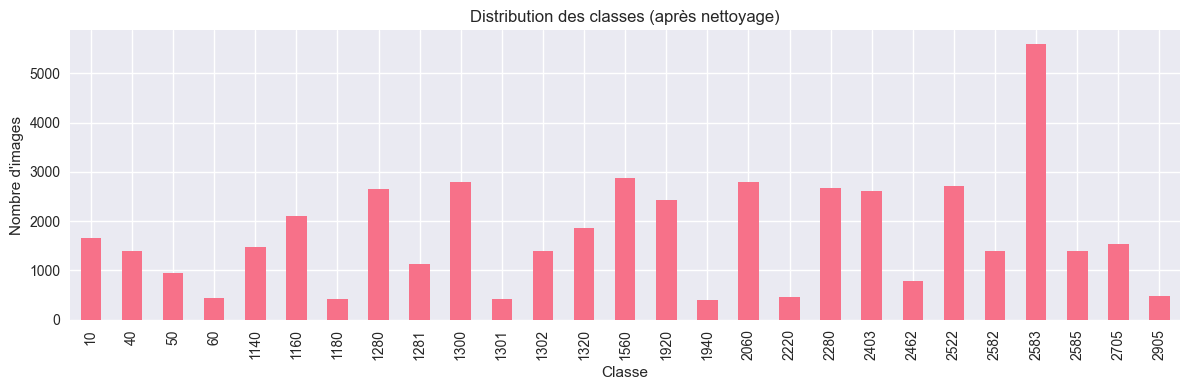

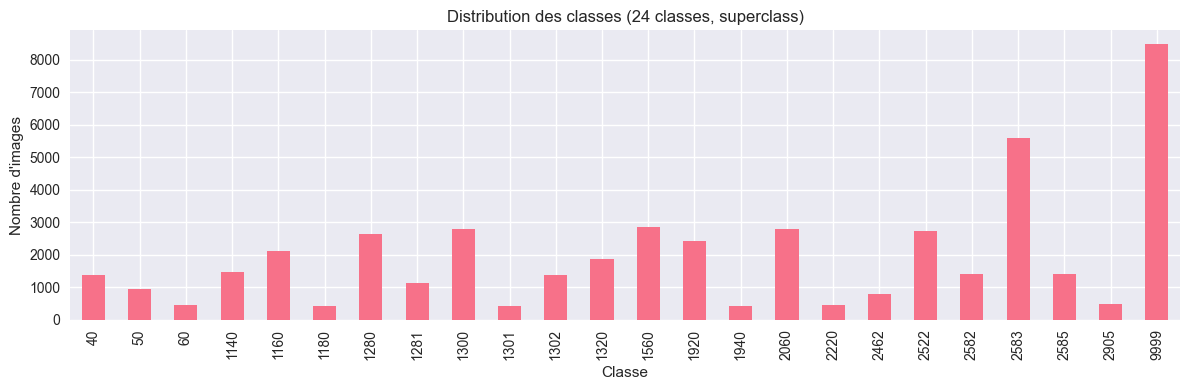

In [12]:
ROOT = Path('../').resolve()
DATA_BRUT = ROOT / 'data brut'
IMAGE_CLEAN_DIR = ROOT / 'data' / 'processed' / 'image_clean'
DATASET_CSV = ROOT / 'data' / 'processed' / 'image_dataset_processed.csv'
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

print("🔄 Chargement des données images...")
if DATASET_CSV.exists():
    image_df = pd.read_csv(DATASET_CSV)
    print(f"✅ Dataset chargé depuis {DATASET_CSV.name}")
else:
    image_df = load_image_classification_data(DATA_BRUT, IMAGE_CLEAN_DIR, root=ROOT)
    print("✅ Dataset construit depuis image_clean")

# Si le CSV ne contient pas de labels (cas test/brut), on reconstruit depuis le train
if 'prdtypecode' not in image_df.columns or image_df['prdtypecode'].isna().all():
    print("⚠️ CSV sans labels, reconstruction depuis image_clean + Y_train...")
    image_df = load_image_classification_data(DATA_BRUT, IMAGE_CLEAN_DIR, root=ROOT)

# Choix du chemin d'image à utiliser
if 'image_path_clean' in image_df.columns and image_df['image_path_clean'].notna().any():
    image_path_col = 'image_path_clean'
else:
    image_path_col = 'image_path'

# Vérification labels
if 'prdtypecode' not in image_df.columns or image_df['prdtypecode'].isna().all() or len(image_df) == 0:
    raise RuntimeError("Aucun label disponible. Vérifie que tu utilises des images train nettoyées.")

print(f"✅ {len(image_df):,} produits avec image chargés")
print(f"   - Colonne images : {image_path_col}")
print(f"   - Nombre de classes : {image_df['prdtypecode'].nunique()}")
print(f"   - Distribution (top 5) :")
print(image_df['prdtypecode'].value_counts().head())

# Distribution complète après nettoyage (27 classes)
class_counts = image_df['prdtypecode'].value_counts().sort_index()
print("\n📊 Distribution des classes (après nettoyage) :")
print(class_counts.to_string())

plt.figure(figsize=(12, 4))
class_counts.plot(kind='bar')
plt.title('Distribution des classes (après nettoyage)')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'images')
plt.tight_layout()

# Distribution en 24 classes (superclass)
CODE_SUPERCLASSE = 9999
PUBLICATIONS_CLASSES = {10, 2280, 2403, 2705}
image_df['prdtypecode_superclass'] = image_df['prdtypecode'].apply(
    lambda x: CODE_SUPERCLASSE if x in PUBLICATIONS_CLASSES else x
)
class_counts_sc = image_df['prdtypecode_superclass'].value_counts().sort_index()
print("\n📊 Distribution des classes (24 classes, superclass) :")
print(class_counts_sc.to_string())

plt.figure(figsize=(12, 4))
class_counts_sc.plot(kind='bar')
plt.title('Distribution des classes (24 classes, superclass)')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'images')
plt.tight_layout()

## 2. Extraction des Features (ResNet50)

Extraction des features 2048-dim à partir du backbone ResNet50 pré-entraîné ImageNet. **Option** : sauvegarde/cache des features pour éviter de ré-extraire à chaque exécution.

In [3]:
FEATURES_CACHE = MODELS_DIR / 'image_features_cache.npz'

if FEATURES_CACHE.exists():
    print("🔄 Chargement des features depuis le cache...")
    cache = np.load(FEATURES_CACHE, allow_pickle=True)
    X_features = cache['X']
    y_labels = cache['y']
    indices = cache['indices']
    print(f"✅ Features chargées : {X_features.shape}")
else:
    print("🔄 Extraction des features (ResNet50)...")
    extractor = ImageFeatureExtractor(output_dim=2048)
    X_features = extractor.extract_from_paths(
        image_df[image_path_col].tolist(),
        base_dir=ROOT,
        batch_size=32,
        show_progress=True
    )
    y_labels = image_df['prdtypecode'].values
    indices = np.arange(len(image_df))
    np.savez(FEATURES_CACHE, X=X_features, y=y_labels, indices=indices)
    print(f"✅ Features extraites et sauvegardées : {X_features.shape}")

🔄 Extraction des features (ResNet50)...


Extraction des features: 100%|██████████| 1465/1465 [11:04<00:00,  2.20batch/s]


✅ Features extraites et sauvegardées : (46857, 2048)


## 3. Préparation des Labels et Split Train/Validation

In [4]:
# Superclasse (24 classes) : Publications -> 9999
CODE_SUPERCLASSE = 9999
PUBLICATIONS_CLASSES = {10, 2280, 2403, 2705}

y_labels_superclass = np.array([
    CODE_SUPERCLASSE if y in PUBLICATIONS_CLASSES else y
    for y in y_labels
])

# Label encoders
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

label_encoder_superclass = LabelEncoder()
y_encoded_sc = label_encoder_superclass.fit_transform(y_labels_superclass)

SCENARIOS = [
    ("27 classes", y_encoded, label_encoder),
    ("24 classes (superclass)", y_encoded_sc, label_encoder_superclass)
]

from sklearn.model_selection import train_test_split
indices = np.arange(len(y_labels))
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train_split = X_features[train_idx]
X_val_split = X_features[val_idx]
splits_by_scenario = {name: (y_enc[train_idx], y_enc[val_idx]) for name, y_enc, _ in SCENARIOS}

print(f"✅ Train : {X_train_split.shape[0]:,} | Validation : {X_val_split.shape[0]:,}")
print(f"   Features : {X_train_split.shape[1]} dimensions")
print(f"✅ Scénarios : {[s[0] for s in SCENARIOS]}")

✅ Train : 37,485 | Validation : 9,372
   Features : 2048 dimensions
✅ Scénarios : ['27 classes', '24 classes (superclass)']


In [5]:
with open(MODELS_DIR / 'label_encoder_image.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
with open(MODELS_DIR / 'label_encoder_image_superclass.pkl', 'wb') as f:
    pickle.dump(label_encoder_superclass, f)
print("✅ Label encoders image sauvegardés (27 et 24 classes)")

✅ Label encoders image sauvegardés (27 et 24 classes)


## 4. Entraînement des Modèles Baselines

In [6]:
from sklearn.naive_bayes import GaussianNB

baseline_models_by_scenario = {}
trained_models_by_scenario = {}

for scenario_name, _, _ in SCENARIOS:
    y_train_s, _ = splits_by_scenario[scenario_name]
    print(f"\n🔄 Entraînement des baselines - {scenario_name}...")

    baseline_models = BaselineModels(random_state=42)
    baseline_models.create_baseline_models()
    baseline_models.models['Naive Bayes'] = GaussianNB()  # adapté aux features continues
    trained_models = baseline_models.train_all_models(X_train_split, y_train_s)

    baseline_models_by_scenario[scenario_name] = baseline_models
    trained_models_by_scenario[scenario_name] = trained_models

print("\n✅ Tous les modèles baselines entraînés (27 et 24 classes)")


🔄 Entraînement des baselines - 27 classes...
🔄 Entraînement de Naive Bayes...
✅ Naive Bayes entraîné avec succès
🔄 Entraînement de Logistic Regression...
✅ Logistic Regression entraîné avec succès
🔄 Entraînement de SVM (Linear)...
✅ SVM (Linear) entraîné avec succès
🔄 Entraînement de Random Forest...
✅ Random Forest entraîné avec succès

🔄 Entraînement des baselines - 24 classes (superclass)...
🔄 Entraînement de Naive Bayes...
✅ Naive Bayes entraîné avec succès
🔄 Entraînement de Logistic Regression...
✅ Logistic Regression entraîné avec succès
🔄 Entraînement de SVM (Linear)...
✅ SVM (Linear) entraîné avec succès
🔄 Entraînement de Random Forest...
✅ Random Forest entraîné avec succès

✅ Tous les modèles baselines entraînés (27 et 24 classes)


## 5. Évaluation et Comparaison

In [7]:
results_summary = []
for scenario_name, _, _ in SCENARIOS:
    _, y_val_s = splits_by_scenario[scenario_name]
    baseline_models = baseline_models_by_scenario[scenario_name]
    trained_models = trained_models_by_scenario[scenario_name]

    for model_name in trained_models.keys():
        y_pred = baseline_models.predict(model_name, X_val_split)
        metrics = evaluate_model(y_val_s, y_pred)
        results_summary.append({
            'Scenario': scenario_name,
            'Model': model_name,
            'Accuracy': metrics['accuracy'],
            'F1_macro': metrics['f1_macro'],
            'F1_weighted': metrics['f1_weighted']
        })

results_df = pd.DataFrame(results_summary).sort_values(['Scenario', 'F1_macro'], ascending=[True, False])
print(results_df.to_string(index=False))

# Tableaux séparés par scénario
for scenario in results_df['Scenario'].unique():
    print(f"\n{'-'*80}")
    print(f"TABLEAU RÉSULTATS - {scenario}")
    print(f"{'-'*80}")
    scenario_df = results_df[results_df['Scenario'] == scenario]
    print(scenario_df.to_string(index=False))

               Scenario               Model  Accuracy  F1_macro  F1_weighted
24 classes (superclass) Logistic Regression  0.107341  0.043355     0.086208
24 classes (superclass)        SVM (Linear)  0.104887  0.038823     0.080324
24 classes (superclass)         Naive Bayes  0.023688  0.024885     0.020164
24 classes (superclass)       Random Forest  0.177657  0.017202     0.064022
             27 classes Logistic Regression  0.064981  0.041479     0.059412
             27 classes        SVM (Linear)  0.058045  0.036272     0.052768
             27 classes         Naive Bayes  0.023794  0.023823     0.020700
             27 classes       Random Forest  0.116837  0.009877     0.028078

--------------------------------------------------------------------------------
TABLEAU RÉSULTATS - 24 classes (superclass)
--------------------------------------------------------------------------------
               Scenario               Model  Accuracy  F1_macro  F1_weighted
24 classes (superclass)

## 6. Validation Croisée

Validation croisée pour obtenir une estimation plus robuste des performances.

In [ ]:
from sklearn.naive_bayes import GaussianNB

cv_results = []
cv_models = BaselineModels(random_state=SEED)
cv_models.create_baseline_models()
cv_models.models['Naive Bayes'] = GaussianNB()

print("VALIDATION CROISÉE (5 folds)")
for scenario_name, y_enc, _ in SCENARIOS:
    print(f"\n🔄 Validation croisée - {scenario_name}...")
    for model_name in cv_models.models.keys():
        print(f"   - {model_name}...")
        res = cv_models.cross_validate(model_name, X_features, y_enc, cv=5, scoring='f1_macro')
        cv_results.append({
            'Scenario': scenario_name,
            'Model': model_name,
            'CV_F1_mean': res['mean'],
            'CV_F1_std': res['std']
        })

cv_df = pd.DataFrame(cv_results).sort_values(['Scenario', 'CV_F1_mean'], ascending=[True, False])
print("\nRÉSULTATS DE VALIDATION CROISÉE")
print(cv_df.to_string(index=False))

## 6. Meilleur Modèle - Matrice de Confusion


MATRICE DE CONFUSION - Logistic Regression (24 classes (superclass))


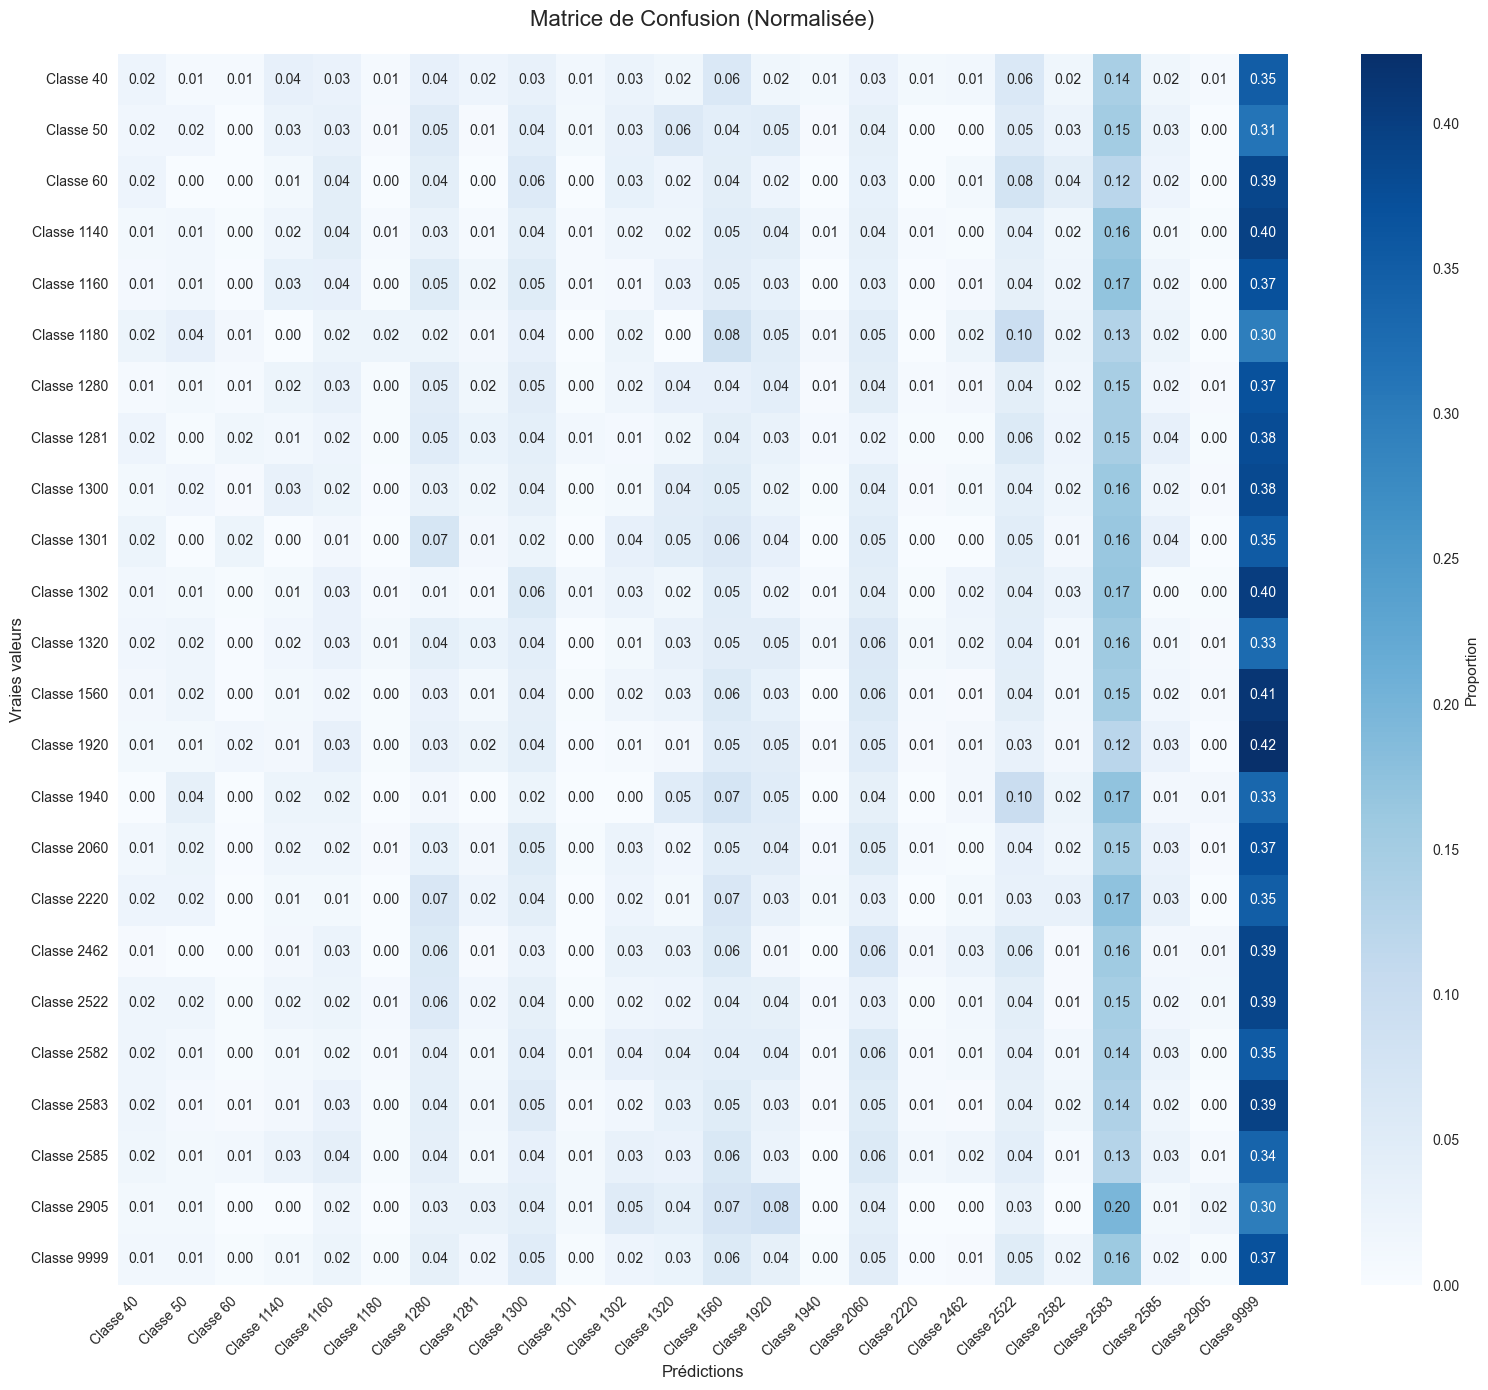


MATRICE DE CONFUSION - Logistic Regression (27 classes)


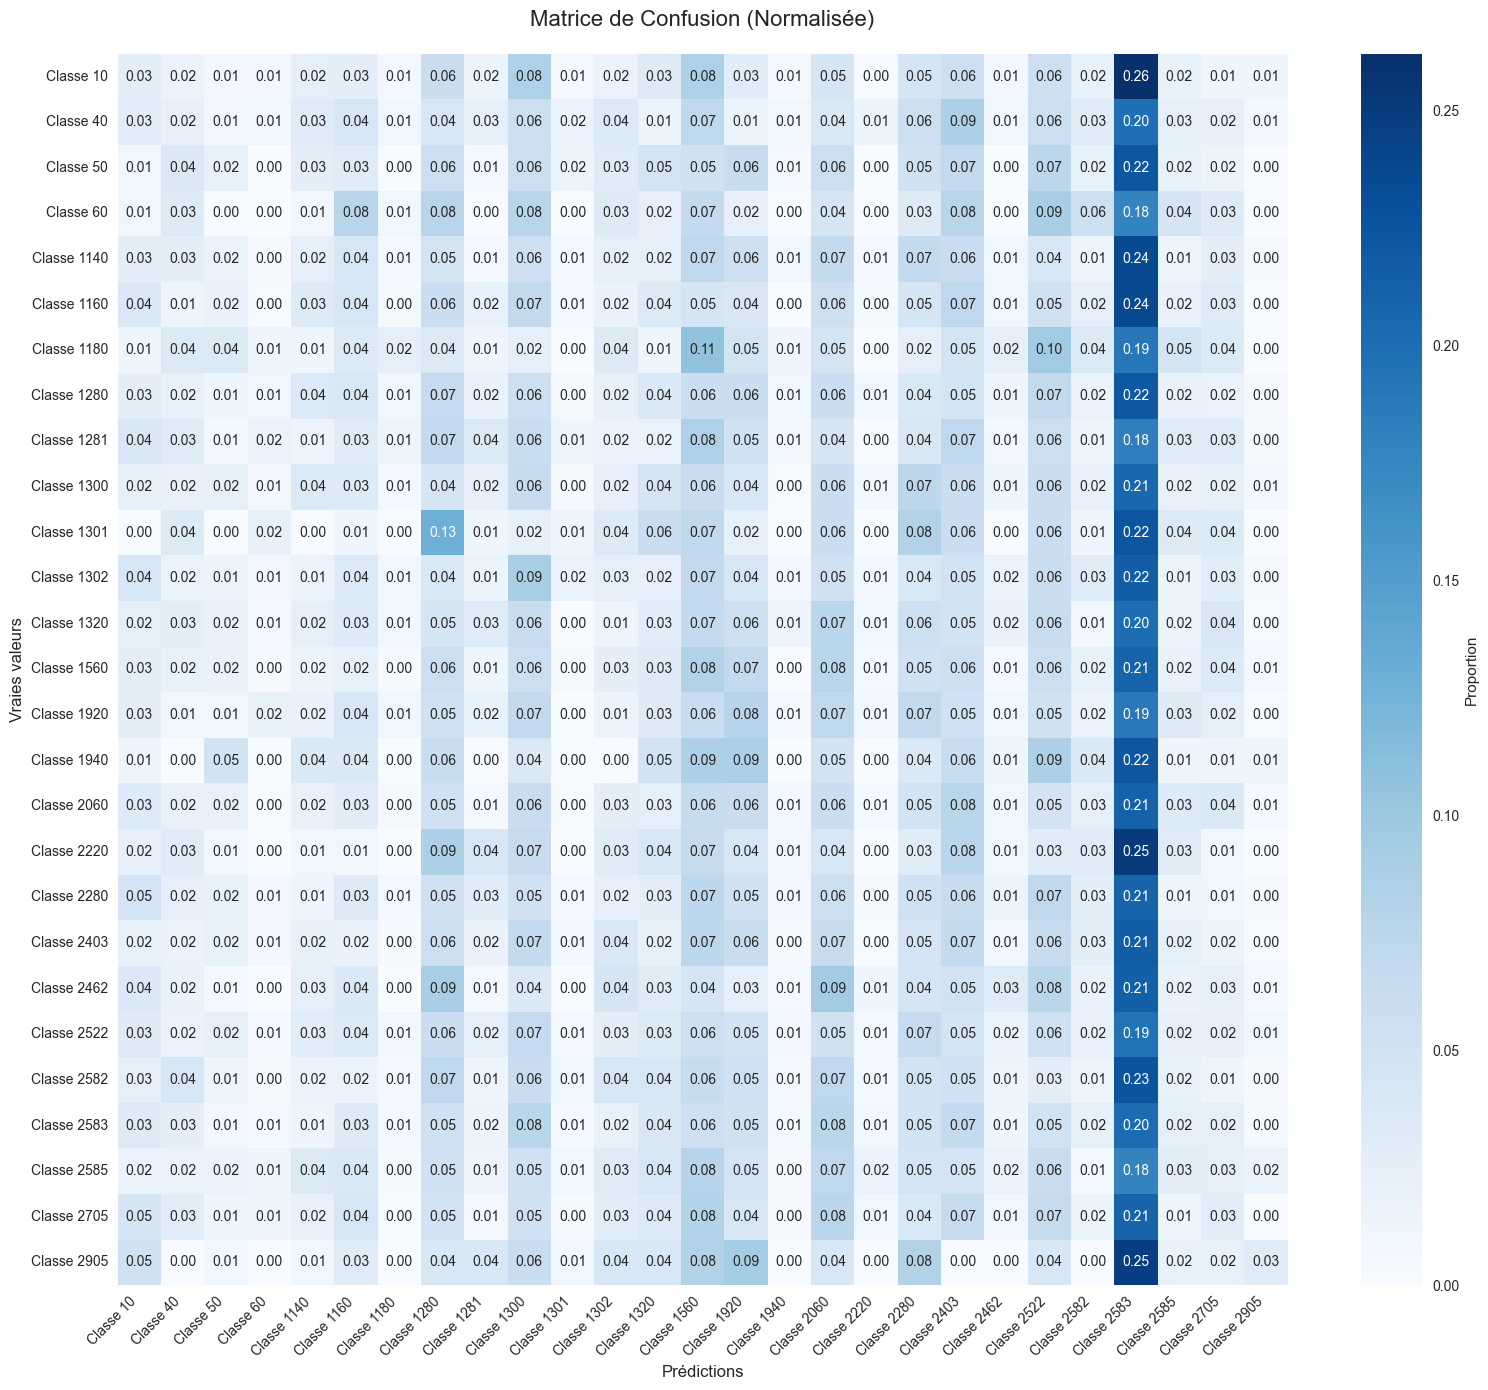

In [8]:
for scenario in results_df['Scenario'].unique():
    scenario_df = results_df[results_df['Scenario'] == scenario]
    best_name = scenario_df.iloc[0]['Model']

    baseline_models = baseline_models_by_scenario[scenario]
    _, y_val_s = splits_by_scenario[scenario]
    y_pred_best = baseline_models.predict(best_name, X_val_split)

    label_encoder_s = label_encoder if scenario == "27 classes" else label_encoder_superclass
    class_names = [f"Classe {c}" for c in sorted(label_encoder_s.classes_)]

    print(f"\nMATRICE DE CONFUSION - {best_name} ({scenario})")
    plot_confusion_matrix(y_val_s, y_pred_best, class_names=class_names, figsize=(16, 14), normalize=True)

## 7. Sauvegarde du Meilleur Modèle

In [9]:
for scenario in results_df['Scenario'].unique():
    scenario_df = results_df[results_df['Scenario'] == scenario]
    best_name = scenario_df.iloc[0]['Model']

    baseline_models = baseline_models_by_scenario[scenario]
    scenario_suffix = "superclass" if "superclass" in scenario.lower() else "27_classes"
    model_path = MODELS_DIR / f"image_{best_name.lower().replace(' ', '_')}_{scenario_suffix}_baseline.pkl"
    baseline_models.save_model(best_name, model_path)

results_df.to_csv(MODELS_DIR / 'image_baseline_comparison.csv', index=False)
print("✅ Modèles et résultats sauvegardés (27 et 24 classes)")

✅ Modèles et résultats sauvegardés (27 et 24 classes)
